In [1]:
# =====================================
# 1. DATA LOADING AND PREPROCESSING
# =====================================

import pandas as pd
import numpy as np
from pathlib import Path


# ---------------------
# OUTPUT DIRECTORIES
# ---------------------

results_dir = Path("../results")
figures_dir = Path("../figures")
tables_dir = Path("../tables")

for path in [results_dir, figures_dir, tables_dir]:
    path.mkdir(parents=True, exist_ok=True)


# ---------------------
# LOAD DATA
# ---------------------

data_path = Path("../data/raw/GDPa1_v1.2_20250814.csv")
df = pd.read_csv(data_path)


# ---------------------
# KEEP RELEVANT COLUMNS
# ---------------------

df = df[[
    "antibody_id",
    "vh_protein_sequence",
    "vl_protein_sequence",
    "HIC",
    "AC-SINS_pH7.4",
    "hierarchical_cluster_IgG_isotype_stratified_fold"
]].copy()


# ---------------------
# RENAME TARGET
# ---------------------

df = df.rename(columns={
    "AC-SINS_pH7.4": "AC_SINS"
})


# ---------------------
# ENSURE NUMERIC TARGETS
# ---------------------

target_cols = ["HIC", "AC_SINS"]

for col in target_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# ---------------------
# CLEAN SEQUENCES
# ---------------------

sequence_cols = [
    "vh_protein_sequence",
    "vl_protein_sequence"
]

for col in sequence_cols:

    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)
        .str.strip()
    )


# ---------------------
# REMOVE INVALID SEQUENCES
# ---------------------

valid_aas = set("ACDEFGHIKLMNPQRSTVWY")

valid_vh = (
    (df["vh_protein_sequence"].str.len() > 0) &
    (
        df["vh_protein_sequence"]
        .apply(lambda seq: set(seq).issubset(valid_aas))
    )
)

valid_vl = (
    (df["vl_protein_sequence"].str.len() > 0) &
    (
        df["vl_protein_sequence"]
        .apply(lambda seq: set(seq).issubset(valid_aas))
    )
)

invalid_sequences = df[
    ~(valid_vh & valid_vl)
][[
    "antibody_id",
    "vh_protein_sequence",
    "vl_protein_sequence"
]]

print("Invalid sequence rows:", len(invalid_sequences))

if len(invalid_sequences) > 0:

    invalid_sequences.to_csv(
        results_dir / "invalid_sequences.csv",
        index=False
    )

    print("Saved invalid_sequences.csv")

df = df[
    valid_vh & valid_vl
].copy()


# ---------------------
# RESET INDEX
# ---------------------

df = df.reset_index(drop=True)


# ---------------------
# DATASET SUMMARY
# ---------------------

print("Total antibodies:", len(df))
print("HIC available:", df["HIC"].notna().sum())
print("AC-SINS available:", df["AC_SINS"].notna().sum())

print(
    "Cluster folds:",
    df["hierarchical_cluster_IgG_isotype_stratified_fold"].nunique()
)

Invalid sequence rows: 0
Total antibodies: 246
HIC available: 242
AC-SINS available: 242
Cluster folds: 5


In [2]:
# =====================================
# 2. GLOBAL SEQUENCE FEATURES
# =====================================

def compute_global_features(sequence):
    """
    Compute simple interpretable sequence-level features.
    """

    length = len(sequence)

    if length == 0:
        return {
            "length": 0,
            "hydrophobic": 0,
            "aromatic": 0,
            "charge": 0,
            "polar": 0,
            "glycine": 0,
            "proline": 0,
            "cysteine": 0
        }

    hydrophobic_aas = set("AILMFWYV")
    aromatic_aas = set("FWY")
    polar_aas = set("STNQ")

    hydrophobic_frac = (
        sum(aa in hydrophobic_aas for aa in sequence) / length
    )

    aromatic_frac = (
        sum(aa in aromatic_aas for aa in sequence) / length
    )

    polar_frac = (
        sum(aa in polar_aas for aa in sequence) / length
    )

    glycine_frac = (
        sum(aa == "G" for aa in sequence) / length
    )

    proline_frac = (
        sum(aa == "P" for aa in sequence) / length
    )

    cysteine_frac = (
        sum(aa == "C" for aa in sequence) / length
    )

    positive = sum(aa in "KR" for aa in sequence)
    negative = sum(aa in "DE" for aa in sequence)

    net_charge = (positive - negative) / length

    return {
        "length": length,
        "hydrophobic": hydrophobic_frac,
        "aromatic": aromatic_frac,
        "charge": net_charge,
        "polar": polar_frac,
        "glycine": glycine_frac,
        "proline": proline_frac,
        "cysteine": cysteine_frac
    }


# ---------------------
# HEAVY CHAIN FEATURES
# ---------------------

vh_features = pd.DataFrame([
    compute_global_features(seq)
    for seq in df["vh_protein_sequence"]
])

vh_features.columns = [
    f"vh_{col}" for col in vh_features.columns
]


# ---------------------
# LIGHT CHAIN FEATURES
# ---------------------

vl_features = pd.DataFrame([
    compute_global_features(seq)
    for seq in df["vl_protein_sequence"]
])

vl_features.columns = [
    f"vl_{col}" for col in vl_features.columns
]


# ---------------------
# COMBINE FEATURES
# ---------------------

X_global = pd.concat(
    [vh_features, vl_features],
    axis=1
).astype(float)

print("Global feature shape:", X_global.shape)


# ---------------------
# VALIDATE GLOBAL FEATURES
# ---------------------

print("\nMissing values:")
print(X_global.isna().sum().sum())

fraction_features = [
    col for col in X_global.columns
    if any(
        name in col
        for name in [
            "hydrophobic",
            "aromatic",
            "polar",
            "glycine",
            "proline",
            "cysteine"
        ]
    )
]

print("\nFeature ranges:")

print(
    "Fraction feature min:",
    X_global[fraction_features].min().min()
)

print(
    "Fraction feature max:",
    X_global[fraction_features].max().max()
)

print(
    "Charge min:",
    X_global.filter(like="charge").min().min()
)

print(
    "Charge max:",
    X_global.filter(like="charge").max().max()
)

print(
    "Length min:",
    X_global.filter(like="length").min().min()
)

print(
    "Length max:",
    X_global.filter(like="length").max().max()
)

Global feature shape: (246, 16)

Missing values:
0

Feature ranges:
Fraction feature min: 0.007936507936507936
Fraction feature max: 0.44881889763779526
Charge min: -0.05405405405405406
Charge max: 0.058823529411764705
Length min: 104.0
Length max: 130.0


In [3]:
# =====================================
# 3. REGION-LEVEL SEQUENCE FEATURES (ANARCI/AHO)
# =====================================

from anarci import anarci


# ---------------------
# AHO REGION DEFINITIONS
# ---------------------

REGION_RANGES = {
    "FR1": range(1, 27),
    "CDR1": range(27, 39),
    "FR2": range(39, 56),
    "CDR2": range(56, 66),
    "FR3": range(66, 105),
    "CDR3": range(105, 118),
    "FR4": range(118, 129)
}


# ---------------------
# REGION EXTRACTION
# ---------------------

def extract_regions(numbered_residues):

    regions = {}

    for region_name, positions in REGION_RANGES.items():

        region_seq = "".join(
            aa
            for position, insertion, aa in numbered_residues
            if position in positions
        )

        regions[region_name] = region_seq

    return regions


# ---------------------
# REGION FEATURES
# ---------------------

def compute_region_features(sequence):

    length = len(sequence)

    if length == 0:
        return {
            "length": 0,
            "hydrophobic": 0,
            "aromatic": 0,
            "charge": 0,
            "polar": 0,
            "glycine": 0,
            "proline": 0,
            "cysteine": 0
        }

    hydrophobic_aas = set("AILMFWYV")
    aromatic_aas = set("FWY")
    polar_aas = set("STNQ")

    hydrophobic_frac = (
        sum(aa in hydrophobic_aas for aa in sequence) / length
    )

    aromatic_frac = (
        sum(aa in aromatic_aas for aa in sequence) / length
    )

    polar_frac = (
        sum(aa in polar_aas for aa in sequence) / length
    )

    glycine_frac = (
        sum(aa == "G" for aa in sequence) / length
    )

    proline_frac = (
        sum(aa == "P" for aa in sequence) / length
    )

    cysteine_frac = (
        sum(aa == "C" for aa in sequence) / length
    )

    positive = sum(aa in "KR" for aa in sequence)
    negative = sum(aa in "DE" for aa in sequence)

    net_charge = (positive - negative) / length

    return {
        "length": length,
        "hydrophobic": hydrophobic_frac,
        "aromatic": aromatic_frac,
        "charge": net_charge,
        "polar": polar_frac,
        "glycine": glycine_frac,
        "proline": proline_frac,
        "cysteine": cysteine_frac
    }


# ---------------------
# ANARCI NUMBERING
# ---------------------

def process_sequence(seq_id, sequence):

    try:

        result, _, _ = anarci([
            (str(seq_id), sequence)
        ])

        if (
            result is None or
            result[0] is None or
            result[0][0] is None
        ):
            raise ValueError("ANARCI returned no numbering")

        output = result[0][0][0]

        numbered_residues = []

        for ((position, insertion), aa) in output:

            if aa != "-":
                numbered_residues.append(
                    (position, insertion, aa)
                )

        if len(numbered_residues) == 0:
            raise ValueError("ANARCI returned no numbered residues")

        return extract_regions(numbered_residues), True, ""

    except Exception as error:

        empty_regions = {
            region: ""
            for region in REGION_RANGES.keys()
        }

        return empty_regions, False, str(error)


# ---------------------
# BUILD REGION FEATURES
# ---------------------

region_feature_rows = []
anarci_validation_rows = []

for i in range(len(df)):

    antibody_id = df.loc[i, "antibody_id"]

    vh_regions, vh_success, vh_error = process_sequence(
        antibody_id,
        df.loc[i, "vh_protein_sequence"]
    )

    vl_regions, vl_success, vl_error = process_sequence(
        antibody_id,
        df.loc[i, "vl_protein_sequence"]
    )

    feature_dict = {}

    # heavy chain
    for region_name, region_seq in vh_regions.items():

        region_features = compute_region_features(
            region_seq
        )

        for feature_name, value in region_features.items():

            feature_dict[
                f"vh_{region_name}_{feature_name}"
            ] = value

    # light chain
    for region_name, region_seq in vl_regions.items():

        region_features = compute_region_features(
            region_seq
        )

        for feature_name, value in region_features.items():

            feature_dict[
                f"vl_{region_name}_{feature_name}"
            ] = value

    region_feature_rows.append(feature_dict)

    anarci_validation_rows.append({
        "antibody_id": antibody_id,
        "vh_success": vh_success,
        "vl_success": vl_success,
        "vh_numbered_length": sum(
            len(sequence)
            for sequence in vh_regions.values()
        ),
        "vl_numbered_length": sum(
            len(sequence)
            for sequence in vl_regions.values()
        ),
        "vh_error": vh_error,
        "vl_error": vl_error
    })


# ---------------------
# FINAL REGION MATRIX
# ---------------------

X_region = pd.DataFrame(
    region_feature_rows
).astype(float)

anarci_validation = pd.DataFrame(
    anarci_validation_rows
)


# ---------------------
# VALIDATE ANARCI OUTPUT
# ---------------------

vh_failures = (
    ~anarci_validation["vh_success"]
).sum()

vl_failures = (
    ~anarci_validation["vl_success"]
).sum()

print("Region feature shape:", X_region.shape)
print("Missing values:", X_region.isna().sum().sum())
print("ANARCI VH failures:", vh_failures)
print("ANARCI VL failures:", vl_failures)

print(
    "VH numbered length range:",
    anarci_validation["vh_numbered_length"].min(),
    "to",
    anarci_validation["vh_numbered_length"].max()
)

print(
    "VL numbered length range:",
    anarci_validation["vl_numbered_length"].min(),
    "to",
    anarci_validation["vl_numbered_length"].max()
)


# ---------------------
# SAVE ANARCI FAILURES
# ---------------------

anarci_failures = anarci_validation[
    (~anarci_validation["vh_success"]) |
    (~anarci_validation["vl_success"])
].copy()

if len(anarci_failures) > 0:

    anarci_failures.to_csv(
        results_dir / "anarci_failures.csv",
        index=False
    )

    print("Saved anarci_failures.csv")

Region feature shape: (246, 112)
Missing values: 0
ANARCI VH failures: 0
ANARCI VL failures: 0
VH numbered length range: 111 to 130
VL numbered length range: 104 to 113


In [4]:
# =====================================
# 4. STRUCTURE-DERIVED FEATURES
# (ABodyBuilder2 + FreeSASA)
# =====================================

from ImmuneBuilder import ABodyBuilder2
import freesasa
import os


# ---------------------
# INITIALIZE STRUCTURE MODEL
# ---------------------

builder = ABodyBuilder2()

structure_path = results_dir / "X_structure.csv"
temp_dir = results_dir / "temp_structures"
temp_dir.mkdir(parents=True, exist_ok=True)


# ---------------------
# SASA FEATURE EXTRACTION
# ---------------------

def extract_structure_features(pdb_path):
    """
    Extract simple surface descriptors from a predicted antibody structure.
    """

    structure = freesasa.Structure(str(pdb_path))
    result = freesasa.calc(structure)

    hydrophobic_residues = {
        "ALA", "ILE", "LEU", "MET",
        "PHE", "TRP", "TYR", "VAL"
    }

    aromatic_residues = {"PHE", "TRP", "TYR"}
    polar_residues = {"SER", "THR", "ASN", "GLN"}

    positive_residues = {"LYS", "ARG"}
    negative_residues = {"ASP", "GLU"}

    exposed_atoms = 0
    exposed_hydrophobic = 0
    exposed_aromatic = 0
    exposed_polar = 0

    surface_charge = 0
    total_sasa = 0.0

    for i in range(structure.nAtoms()):

        residue = structure.residueName(i).strip()
        area = result.atomArea(i)

        if area > 1.0:

            exposed_atoms += 1
            total_sasa += area

            if residue in hydrophobic_residues:
                exposed_hydrophobic += 1

            if residue in aromatic_residues:
                exposed_aromatic += 1

            if residue in polar_residues:
                exposed_polar += 1

            if residue in positive_residues:
                surface_charge += 1

            elif residue in negative_residues:
                surface_charge -= 1

    if exposed_atoms == 0:

        return {
            "surface_hydrophobicity": 0.0,
            "surface_aromaticity": 0.0,
            "surface_polarity": 0.0,
            "surface_charge": 0.0,
            "total_sasa": 0.0
        }

    return {
        "surface_hydrophobicity":
            exposed_hydrophobic / exposed_atoms,

        "surface_aromaticity":
            exposed_aromatic / exposed_atoms,

        "surface_polarity":
            exposed_polar / exposed_atoms,

        "surface_charge":
            surface_charge / exposed_atoms,

        "total_sasa":
            total_sasa
    }


# ---------------------
# BUILD OR LOAD STRUCTURE FEATURES
# ---------------------

if structure_path.exists():

    structure_cache = pd.read_csv(
        structure_path
    )

    # migrate the original cache format once
    if "antibody_id" not in structure_cache.columns:

        if len(structure_cache) != len(df):
            raise ValueError(
                "Old structure cache row count does not "
                "match the current dataset"
            )

        structure_cache.insert(
            0,
            "antibody_id",
            df["antibody_id"].values
        )

        structure_cache.to_csv(
            structure_path,
            index=False
        )

        print(
            "Added antibody IDs to existing structure cache."
        )

    # verify cache IDs and dataset IDs are in the same order
    cached_ids = (
        structure_cache["antibody_id"]
        .astype(str)
        .reset_index(drop=True)
    )

    current_ids = (
        df["antibody_id"]
        .astype(str)
        .reset_index(drop=True)
    )

    if not cached_ids.equals(current_ids):
        raise ValueError(
            "Structure cache antibody IDs do not "
            "match the current dataset order"
        )

    X_structure = structure_cache.drop(
        columns="antibody_id"
    )

    print(
        "Loaded and verified cached structure features."
    )

else:

    structure_feature_rows = []

    for i in range(len(df)):

        antibody_id = df.loc[
            i,
            "antibody_id"
        ]

        vh_sequence = df.loc[
            i,
            "vh_protein_sequence"
        ]

        vl_sequence = df.loc[
            i,
            "vl_protein_sequence"
        ]

        pdb_path = (
            temp_dir /
            f"temp_{antibody_id}.pdb"
        )

        try:

            antibody = builder.predict({
                "H": vh_sequence,
                "L": vl_sequence
            })

            antibody.save(
                str(pdb_path)
            )

            feature_dict = (
                extract_structure_features(
                    pdb_path
                )
            )

        except Exception as error:

            print(
                f"Structure error for "
                f"{antibody_id}: {error}"
            )

            feature_dict = {
                "surface_hydrophobicity": 0.0,
                "surface_aromaticity": 0.0,
                "surface_polarity": 0.0,
                "surface_charge": 0.0,
                "total_sasa": 0.0
            }

        finally:

            if pdb_path.exists():
                pdb_path.unlink()

        structure_feature_rows.append(
            feature_dict
        )

    X_structure = pd.DataFrame(
        structure_feature_rows
    ).astype(float)

    structure_cache = X_structure.copy()

    structure_cache.insert(
        0,
        "antibody_id",
        df["antibody_id"].values
    )

    structure_cache.to_csv(
        structure_path,
        index=False
    )

    print(
        "Saved structure features to cache."
    )


# ---------------------
# FINAL STRUCTURE MATRIX
# ---------------------

X_structure = X_structure.astype(float)
X_structure.index = df.index

print(
    "Structure feature shape:",
    X_structure.shape
)

print(
    X_structure.head()
)


# ---------------------
# VALIDATE STRUCTURE FEATURES
# ---------------------

expected_structure_cols = [
    "surface_hydrophobicity",
    "surface_aromaticity",
    "surface_polarity",
    "surface_charge",
    "total_sasa"
]

missing_structure_cols = [
    col
    for col in expected_structure_cols
    if col not in X_structure.columns
]

if missing_structure_cols:

    raise ValueError(
        f"Missing structure columns: "
        f"{missing_structure_cols}"
    )

print("\nMissing values:")

print(
    X_structure.isna().sum().sum()
)

all_zero_structure_rows = (
    X_structure[
        expected_structure_cols
    ] == 0
).all(axis=1)

print(
    "All-zero structure rows:",
    all_zero_structure_rows.sum()
)

print("\nStructure feature ranges:")

for col in expected_structure_cols:

    print(
        f"{col}:",
        X_structure[col].min(),
        "to",
        X_structure[col].max()
    )

if all_zero_structure_rows.any():

    structure_failures = pd.DataFrame({
        "antibody_id": df.loc[
            all_zero_structure_rows,
            "antibody_id"
        ].values
    })

    structure_failures.to_csv(
        results_dir /
        "structure_failures.csv",
        index=False
    )

    print(
        "Saved structure_failures.csv"
    )


Loaded and verified cached structure features.
Structure feature shape: (246, 5)
   surface_hydrophobicity  surface_aromaticity  surface_polarity  \
0                0.273103             0.143448          0.324138   
1                0.243466             0.129298          0.360385   
2                0.251768             0.094767          0.349364   
3                0.224894             0.106082          0.373409   
4                0.248933             0.098151          0.335704   

   surface_charge    total_sasa  
0        0.067586  10193.219038  
1        0.048143  10132.655953  
2        0.028289   9796.166911  
3        0.014144   9959.717008  
4        0.046942  10028.194563  

Missing values:
0
All-zero structure rows: 0

Structure feature ranges:
surface_hydrophobicity: 0.2060957910014513 to 0.2995720399429387
surface_aromaticity: 0.0685131195335276 to 0.1602288984263233
surface_polarity: 0.2897327707454289 to 0.4112676056338028
surface_charge: -0.041907514450867 to 0.1345609

In [5]:
# =====================================
# 5. REPRESENTATION AND TARGET SETUP
# =====================================

# ---------------------
# ALIGN FEATURE MATRICES
# ---------------------

X_global = X_global.astype(float)
X_region = X_region.astype(float)
X_structure = X_structure.astype(float)

X_global.index = df.index
X_region.index = df.index
X_structure.index = df.index


# ---------------------
# VALIDATE MATRIX ALIGNMENT
# ---------------------

expected_rows = len(df)

for name, X in {
    "Global": X_global,
    "Region": X_region,
    "Structure": X_structure
}.items():

    if len(X) != expected_rows:
        raise ValueError(
            f"{name} row count does not match dataset: "
            f"{len(X)} vs {expected_rows}"
        )

    if not X.index.equals(df.index):
        raise ValueError(
            f"{name} index does not match dataset index"
        )


# ---------------------
# REPRESENTATION DICTIONARY
# ---------------------

representations = {
    "Global": X_global,
    "Region": X_region,
    "Embeddings": None,
    "Structure": X_structure
}


# ---------------------
# TARGETS
# ---------------------

targets = {
    "HIC": "HIC",
    "AC_SINS": "AC_SINS"
}


# ---------------------
# CROSS-VALIDATION FOLDS
# ---------------------

folds = df[
    "hierarchical_cluster_IgG_isotype_stratified_fold"
]


# ---------------------
# DATASET SUMMARY
# ---------------------

print("Global shape:", X_global.shape)
print("Region shape:", X_region.shape)
print("Structure shape:", X_structure.shape)

print("\nTarget availability:")

for target_name, column in targets.items():

    available = df[column].notna().sum()

    print(f"{target_name}: {available}")

Global shape: (246, 16)
Region shape: (246, 112)
Structure shape: (246, 5)

Target availability:
HIC: 242
AC_SINS: 242


In [6]:
# =====================================
# 6. PROTEIN LANGUAGE MODEL EMBEDDINGS
# =====================================

import torch
import esm


embedding_path = results_dir / "X_embeddings.csv"


# ---------------------
# LOAD OR BUILD EMBEDDINGS
# ---------------------

if embedding_path.exists():

    embedding_cache = pd.read_csv(
        embedding_path
    )

    # migrate the original cache format once
    if "antibody_id" not in embedding_cache.columns:

        if len(embedding_cache) != len(df):
            raise ValueError(
                "Old embedding cache row count does not "
                "match the current dataset"
            )

        embedding_cache.insert(
            0,
            "antibody_id",
            df["antibody_id"].values
        )

        embedding_cache.to_csv(
            embedding_path,
            index=False
        )

        print(
            "Added antibody IDs to existing embedding cache."
        )

    # verify cache IDs and dataset IDs are in the same order
    cached_ids = (
        embedding_cache["antibody_id"]
        .astype(str)
        .reset_index(drop=True)
    )

    current_ids = (
        df["antibody_id"]
        .astype(str)
        .reset_index(drop=True)
    )

    if not cached_ids.equals(current_ids):
        raise ValueError(
            "Embedding cache antibody IDs do not "
            "match the current dataset order"
        )

    X_emb = embedding_cache.drop(
        columns="antibody_id"
    )

    print(
        "Loaded and verified cached embeddings."
    )

else:

    # ---------------------
    # LOAD ESM MODEL
    # ---------------------

    model, alphabet = (
        esm.pretrained.esm2_t6_8M_UR50D()
    )

    batch_converter = (
        alphabet.get_batch_converter()
    )

    model.eval()


    # ---------------------
    # EMBEDDING FUNCTION
    # ---------------------

    def get_embedding(seq_id, sequence):

        _, _, tokens = batch_converter([
            (str(seq_id), sequence)
        ])

        with torch.no_grad():

            output = model(
                tokens,
                repr_layers=[6]
            )

        representations = (
            output["representations"][6]
        )

        embedding = (
            representations[0, 1:-1]
            .mean(0)
            .cpu()
            .numpy()
        )

        return embedding


    # ---------------------
    # BUILD EMBEDDINGS
    # ---------------------

    vh_embeddings = []
    vl_embeddings = []

    for i in range(len(df)):

        antibody_id = df.loc[
            i,
            "antibody_id"
        ]

        vh_sequence = df.loc[
            i,
            "vh_protein_sequence"
        ]

        vl_sequence = df.loc[
            i,
            "vl_protein_sequence"
        ]

        vh_embeddings.append(
            get_embedding(
                antibody_id,
                vh_sequence
            )
        )

        vl_embeddings.append(
            get_embedding(
                antibody_id,
                vl_sequence
            )
        )

    X_emb = pd.DataFrame(
        np.hstack([
            vh_embeddings,
            vl_embeddings
        ])
    ).astype(float)

    embedding_cache = X_emb.copy()

    embedding_cache.insert(
        0,
        "antibody_id",
        df["antibody_id"].values
    )

    embedding_cache.to_csv(
        embedding_path,
        index=False
    )

    print(
        "Saved embeddings to cache."
    )


# ---------------------
# FINAL EMBEDDING MATRIX
# ---------------------

X_emb = X_emb.astype(float)
X_emb.index = df.index

print(
    "Embedding shape:",
    X_emb.shape
)


# ---------------------
# VALIDATE EMBEDDINGS
# ---------------------

expected_embedding_dim = 640

if X_emb.shape[1] != expected_embedding_dim:

    raise ValueError(
        "Unexpected embedding dimension: "
        f"{X_emb.shape[1]} instead of "
        f"{expected_embedding_dim}"
    )

if len(X_emb) != len(df):

    raise ValueError(
        "Embedding row count does not match dataset: "
        f"{len(X_emb)} vs {len(df)}"
    )

if not X_emb.index.equals(df.index):

    raise ValueError(
        "Embedding index does not match dataset index"
    )

missing_embedding_values = (
    X_emb.isna().sum().sum()
)

infinite_embedding_values = (
    ~np.isfinite(X_emb.to_numpy())
).sum()

all_zero_embedding_rows = (
    X_emb == 0
).all(axis=1)

print(
    "Missing embedding values:",
    missing_embedding_values
)

print(
    "Infinite embedding values:",
    infinite_embedding_values
)

print(
    "All-zero embedding rows:",
    all_zero_embedding_rows.sum()
)


# ---------------------
# ADD TO REPRESENTATIONS
# ---------------------

representations["Embeddings"] = X_emb

Loaded and verified cached embeddings.
Embedding shape: (246, 640)
Missing embedding values: 0
Infinite embedding values: 0
All-zero embedding rows: 0


In [7]:
# =====================================
# 7. FINAL REPRESENTATION SETUP
# =====================================

# ---------------------
# ALIGN FEATURE MATRICES
# ---------------------

X_global.index = df.index
X_region.index = df.index
X_emb.index = df.index
X_structure.index = df.index

X_global = X_global.astype(float)
X_region = X_region.astype(float)
X_emb = X_emb.astype(float)
X_structure = X_structure.astype(float)


# ---------------------
# VALIDATE FINAL ALIGNMENT
# ---------------------

for name, X in {
    "Global": X_global,
    "Region": X_region,
    "Embeddings": X_emb,
    "Structure": X_structure
}.items():

    if len(X) != len(df):
        raise ValueError(
            f"{name} row count does not match dataset: "
            f"{len(X)} vs {len(df)}"
        )

    if not X.index.equals(df.index):
        raise ValueError(
            f"{name} index does not match dataset index"
        )


# ---------------------
# REPRESENTATION ORDER
# ---------------------

representation_order = [
    "Global",
    "Region",
    "Embeddings",
    "Structure"
]


# ---------------------
# REPRESENTATION DICTIONARY
# ---------------------

representations = {
    "Global": X_global,
    "Region": X_region,
    "Embeddings": X_emb,
    "Structure": X_structure
}


# ---------------------
# TARGETS
# ---------------------

targets = {
    "HIC": "HIC",
    "AC_SINS": "AC_SINS"
}


# ---------------------
# CROSS-VALIDATION FOLDS
# ---------------------

folds = df[
    "hierarchical_cluster_IgG_isotype_stratified_fold"
]


# ---------------------
# DATASET SUMMARY
# ---------------------

print("Representation shapes:")

print("Global:", X_global.shape)
print("Region:", X_region.shape)
print("Embeddings:", X_emb.shape)
print("Structure:", X_structure.shape)

print("\nTarget availability:")

for target_name, column in targets.items():

    available = df[column].notna().sum()

    print(f"{target_name}: {available}")

Representation shapes:
Global: (246, 16)
Region: (246, 112)
Embeddings: (246, 640)
Structure: (246, 5)

Target availability:
HIC: 242
AC_SINS: 242


In [8]:
# =====================================
# 8. MODELING AND EVALUATION
# =====================================

from sklearn.base import clone
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from sklearn.exceptions import ConvergenceWarning

import warnings


# suppress ElasticNet convergence warnings
warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)


# ---------------------
# MODEL DEFINITIONS
# ---------------------

models = {
    "Ridge": Ridge(alpha=1.0),

    "ElasticNet": ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    )
}


# ---------------------
# CROSS-VALIDATION
# ---------------------

def run_cv(model, X, y, folds):
    """
    Run cluster-aware cross-validation using predefined fold labels.

    Returns mean fold metrics, fold-level metrics,
    and out-of-fold predictions.
    """

    fold_records = []

    oof_predictions = pd.Series(
        index=y.index,
        dtype=float
    )

    for fold in sorted(folds.unique()):

        train_mask = folds != fold
        test_mask = folds == fold

        if test_mask.sum() < 2:
            continue

        X_train = X.loc[train_mask]
        X_test = X.loc[test_mask]

        y_train = y.loc[train_mask]
        y_test = y.loc[test_mask]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        X_test_scaled = scaler.transform(
            X_test
        )

        fold_model = clone(model)

        fold_model.fit(
            X_train_scaled,
            y_train
        )

        predictions = fold_model.predict(
            X_test_scaled
        )

        oof_predictions.loc[y_test.index] = (
            predictions
        )

        correlation = spearmanr(
            y_test,
            predictions
        ).correlation

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        fold_records.append({
            "Fold": fold,
            "N_train": len(y_train),
            "N_test": len(y_test),
            "Spearman": correlation,
            "RMSE": rmse
        })

    fold_metrics = pd.DataFrame(
        fold_records
    )

    if len(fold_metrics) == 0:

        spearman_mean = np.nan
        rmse_mean = np.nan

    else:

        spearman_mean = (
            fold_metrics["Spearman"]
            .dropna()
            .mean()
        )

        rmse_mean = (
            fold_metrics["RMSE"]
            .mean()
        )

    return {
        "spearman_mean": float(spearman_mean),
        "rmse_mean": float(rmse_mean),
        "fold_metrics": fold_metrics,
        "oof_predictions": oof_predictions
    }

In [9]:
# =====================================
# 9. RUN MODELS WITH CLUSTER-BASED CV
# =====================================

results = []
fold_results = []
oof_results = []


# ---------------------
# RUN ALL COMBINATIONS
# ---------------------

for target_name, target_column in targets.items():

    target_df = df.dropna(
        subset=[target_column]
    ).copy()

    y = target_df[target_column]

    target_folds = target_df[
        "hierarchical_cluster_IgG_isotype_stratified_fold"
    ]

    for representation_name, X_full in representations.items():

        X = X_full.loc[target_df.index]

        for model_name, model in models.items():

            metrics = run_cv(
                model=model,
                X=X,
                y=y,
                folds=target_folds
            )

            # mean fold metrics
            results.append({
                "Target": target_name,
                "Representation": representation_name,
                "Model": model_name,
                "Spearman": metrics["spearman_mean"],
                "RMSE": metrics["rmse_mean"]
            })

            # fold-level metrics
            fold_metrics = (
                metrics["fold_metrics"]
                .copy()
            )

            fold_metrics.insert(
                0,
                "Model",
                model_name
            )

            fold_metrics.insert(
                0,
                "Representation",
                representation_name
            )

            fold_metrics.insert(
                0,
                "Target",
                target_name
            )

            fold_results.append(
                fold_metrics
            )

            # out-of-fold predictions
            oof_predictions = (
                metrics["oof_predictions"]
                .dropna()
            )

            oof_df = pd.DataFrame({
                "antibody_id": df.loc[
                    oof_predictions.index,
                    "antibody_id"
                ].values,

                "Target": target_name,

                "Representation":
                    representation_name,

                "Model": model_name,

                "Fold": target_folds.loc[
                    oof_predictions.index
                ].values,

                "Observed": y.loc[
                    oof_predictions.index
                ].values,

                "Predicted":
                    oof_predictions.values
            })

            oof_results.append(
                oof_df
            )


# ---------------------
# RESULTS DATAFRAME
# ---------------------

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["Target", "Model", "Spearman"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)


# ---------------------
# FOLD-LEVEL DATAFRAME
# ---------------------

fold_results_df = (
    pd.concat(
        fold_results,
        ignore_index=True
    )
    .sort_values(
        [
            "Target",
            "Model",
            "Representation",
            "Fold"
        ]
    )
    .reset_index(drop=True)
)


# ---------------------
# OUT-OF-FOLD DATAFRAME
# ---------------------

oof_predictions_df = (
    pd.concat(
        oof_results,
        ignore_index=True
    )
    .sort_values(
        [
            "Target",
            "Model",
            "Representation",
            "Fold",
            "antibody_id"
        ]
    )
    .reset_index(drop=True)
)


# ---------------------
# DISPLAY SUMMARY RESULTS
# ---------------------

results_display = results_df.copy()

results_display["Spearman"] = (
    results_display["Spearman"]
    .round(3)
)

results_display["RMSE"] = (
    results_display["RMSE"]
    .round(3)
)

print(results_display)


# ---------------------
# VALIDATE SAVED RESULTS
# ---------------------

expected_combinations = (
    len(targets) *
    len(representations) *
    len(models)
)

expected_fold_rows = (
    expected_combinations *
    folds.nunique()
)

print(
    "\nSummary combinations:",
    len(results_df)
)

print(
    "Fold-level rows:",
    len(fold_results_df)
)

print(
    "OOF prediction rows:",
    len(oof_predictions_df)
)

if len(results_df) != expected_combinations:

    raise ValueError(
        "Unexpected number of summary result rows"
    )

if len(fold_results_df) != expected_fold_rows:

    raise ValueError(
        "Unexpected number of fold-level result rows"
    )


# ---------------------
# SAVE RESULTS
# ---------------------

results_df.to_csv(
    results_dir / "results_summary.csv",
    index=False
)

fold_results_df.to_csv(
    results_dir / "fold_level_metrics.csv",
    index=False
)

oof_predictions_df.to_csv(
    results_dir / "oof_predictions.csv",
    index=False
)

print("\nSaved results_summary.csv")
print("Saved fold_level_metrics.csv")
print("Saved oof_predictions.csv")

     Target Representation       Model  Spearman    RMSE
0   AC_SINS         Global  ElasticNet     0.393   8.257
1   AC_SINS     Embeddings  ElasticNet     0.361   9.549
2   AC_SINS      Structure  ElasticNet     0.307   8.437
3   AC_SINS         Region  ElasticNet     0.302  10.057
4   AC_SINS         Global       Ridge     0.394   8.334
5   AC_SINS      Structure       Ridge     0.301   8.471
6   AC_SINS     Embeddings       Ridge     0.254  12.035
7   AC_SINS         Region       Ridge     0.247  16.578
8       HIC      Structure  ElasticNet     0.458   0.297
9       HIC     Embeddings  ElasticNet     0.301   0.321
10      HIC         Region  ElasticNet     0.259   0.325
11      HIC         Global  ElasticNet     0.210   0.329
12      HIC      Structure       Ridge     0.484   0.291
13      HIC         Region       Ridge     0.449   0.426
14      HIC         Global       Ridge     0.442   0.316
15      HIC     Embeddings       Ridge     0.371   0.392

Summary combinations: 16
Fold-

In [10]:
# =====================================
# 10. RESULTS TABLES
# =====================================

# ---------------------
# SPEARMAN TABLES
# ---------------------

print("\n=== SPEARMAN RESULTS ===")

for target_name in targets.keys():

    table = (
        results_df[
            results_df["Target"] == target_name
        ]
        .pivot(
            index="Model",
            columns="Representation",
            values="Spearman"
        )
    )

    table = table[
        representation_order
    ].round(3)

    print(f"\n--- {target_name} ---")
    print(table.to_string())


# ---------------------
# RMSE TABLES
# ---------------------

print("\n=== RMSE RESULTS ===")

for target_name in targets.keys():

    table = (
        results_df[
            results_df["Target"] == target_name
        ]
        .pivot(
            index="Model",
            columns="Representation",
            values="RMSE"
        )
    )

    table = table[
        representation_order
    ].round(3)

    print(f"\n--- {target_name} ---")
    print(table.to_string())


=== SPEARMAN RESULTS ===

--- HIC ---
Representation  Global  Region  Embeddings  Structure
Model                                                
ElasticNet       0.210   0.259       0.301      0.458
Ridge            0.442   0.449       0.371      0.484

--- AC_SINS ---
Representation  Global  Region  Embeddings  Structure
Model                                                
ElasticNet       0.393   0.302       0.361      0.307
Ridge            0.394   0.247       0.254      0.301

=== RMSE RESULTS ===

--- HIC ---
Representation  Global  Region  Embeddings  Structure
Model                                                
ElasticNet       0.329   0.325       0.321      0.297
Ridge            0.316   0.426       0.392      0.291

--- AC_SINS ---
Representation  Global  Region  Embeddings  Structure
Model                                                
ElasticNet       8.257  10.057       9.549      8.437
Ridge            8.334  16.578      12.035      8.471


In [11]:
# =====================================
# 11. PERFORMANCE METRIC VALIDATION
# =====================================

# ---------------------
# COMPUTE POOLED OOF METRICS
# ---------------------

pooled_records = []

group_cols = [
    "Target",
    "Representation",
    "Model"
]

for group_values, group_df in oof_predictions_df.groupby(
    group_cols
):

    target_name, representation_name, model_name = (
        group_values
    )

    pooled_spearman = spearmanr(
        group_df["Observed"],
        group_df["Predicted"]
    ).correlation

    pooled_rmse = np.sqrt(
        mean_squared_error(
            group_df["Observed"],
            group_df["Predicted"]
        )
    )

    pooled_records.append({
        "Target": target_name,
        "Representation": representation_name,
        "Model": model_name,
        "Pooled_Spearman": pooled_spearman,
        "Pooled_RMSE": pooled_rmse,
        "N_OOF": len(group_df)
    })


# ---------------------
# POOLED RESULTS DATAFRAME
# ---------------------

pooled_metrics_df = pd.DataFrame(
    pooled_records
)


# ---------------------
# COMBINE WITH MEAN-FOLD METRICS
# ---------------------

metric_comparison_df = results_df.rename(
    columns={
        "Spearman": "MeanFold_Spearman",
        "RMSE": "MeanFold_RMSE"
    }
).merge(
    pooled_metrics_df,
    on=[
        "Target",
        "Representation",
        "Model"
    ],
    how="left",
    validate="one_to_one"
)


# ---------------------
# CALCULATE DIFFERENCES
# ---------------------

metric_comparison_df[
    "Spearman_Difference"
] = (
    metric_comparison_df["Pooled_Spearman"] -
    metric_comparison_df["MeanFold_Spearman"]
)

metric_comparison_df[
    "RMSE_Difference"
] = (
    metric_comparison_df["Pooled_RMSE"] -
    metric_comparison_df["MeanFold_RMSE"]
)


# ---------------------
# ORDER RESULTS
# ---------------------

metric_comparison_df = (
    metric_comparison_df
    .sort_values(
        [
            "Target",
            "Model",
            "Representation"
        ]
    )
    .reset_index(drop=True)
)


# ---------------------
# VALIDATE
# ---------------------

expected_rows = (
    len(targets) *
    len(representations) *
    len(models)
)

if len(metric_comparison_df) != expected_rows:

    raise ValueError(
        "Unexpected number of metric-comparison rows"
    )

if not (
    metric_comparison_df["N_OOF"] == 242
).all():

    raise ValueError(
        "Some model combinations do not contain "
        "242 out-of-fold predictions"
    )


# ---------------------
# DISPLAY
# ---------------------

comparison_display = (
    metric_comparison_df.copy()
)

metric_cols = [
    "MeanFold_Spearman",
    "Pooled_Spearman",
    "Spearman_Difference",
    "MeanFold_RMSE",
    "Pooled_RMSE",
    "RMSE_Difference"
]

comparison_display[metric_cols] = (
    comparison_display[metric_cols]
    .round(3)
)

print(
    comparison_display.to_string(
        index=False
    )
)


# ---------------------
# SAVE
# ---------------------

metric_comparison_df.to_csv(
    results_dir /
    "mean_fold_vs_pooled_oof_metrics.csv",
    index=False
)

print(
    "\nSaved mean_fold_vs_pooled_oof_metrics.csv"
)

 Target Representation      Model  MeanFold_Spearman  MeanFold_RMSE  Pooled_Spearman  Pooled_RMSE  N_OOF  Spearman_Difference  RMSE_Difference
AC_SINS     Embeddings ElasticNet              0.361          9.549            0.337        9.586    242               -0.024            0.038
AC_SINS         Global ElasticNet              0.393          8.257            0.355        8.320    242               -0.038            0.062
AC_SINS         Region ElasticNet              0.302         10.057            0.279       10.063    242               -0.022            0.006
AC_SINS      Structure ElasticNet              0.307          8.437            0.269        8.509    242               -0.038            0.071
AC_SINS     Embeddings      Ridge              0.254         12.035            0.261       12.040    242                0.007            0.005
AC_SINS         Global      Ridge              0.394          8.334            0.363        8.400    242               -0.032            0.067

In [12]:
# =====================================
# 12. INTERPRETABILITY ANALYSIS (RIDGE)
# =====================================

# ---------------------
# PRIMARY INTERPRETATION TARGET
# ---------------------

interpretation_df = df.dropna(
    subset=["HIC"]
).copy()

y_interpret = interpretation_df["HIC"]


# ---------------------
# COEFFICIENT FUNCTION
# ---------------------

def get_ridge_coefficients(X, y, top_n=15):
    """
    Fit Ridge regression on standardized features and return top coefficients.
    """

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    model = Ridge(alpha=1.0)

    model.fit(X_scaled, y)

    coefficients = pd.Series(
        model.coef_,
        index=X.columns
    )

    coefficients = coefficients.sort_values(
        key=abs,
        ascending=False
    )

    return coefficients.head(top_n)


# ---------------------
# GLOBAL FEATURES
# ---------------------

coef_global = get_ridge_coefficients(
    X_global.loc[interpretation_df.index],
    y_interpret,
    top_n=15
)

print("\n--- Global Feature Coefficients ---")
print(coef_global.round(3).to_string())


# ---------------------
# REGION FEATURES
# ---------------------

coef_region = get_ridge_coefficients(
    X_region.loc[interpretation_df.index],
    y_interpret,
    top_n=15
)

print("\n--- Region Feature Coefficients ---")
print(coef_region.round(3).to_string())


# ---------------------
# OPTIONAL STRUCTURE FEATURES
# ---------------------

coef_structure = get_ridge_coefficients(
    X_structure.loc[interpretation_df.index],
    y_interpret,
    top_n=5
)

print("\n--- Structure Feature Coefficients (optional) ---")
print(coef_structure.round(3).to_string())


# ---------------------
# SAVE COEFFICIENT TABLES
# ---------------------

coef_global.to_csv(
    results_dir / "global_coefficients.csv"
)

coef_region.to_csv(
    results_dir / "region_coefficients.csv"
)

coef_structure.to_csv(
    results_dir / "structure_coefficients_optional.csv"
)

print("\nSaved coefficient tables.")


--- Global Feature Coefficients ---
vh_hydrophobic    0.131
vl_glycine        0.106
vh_polar          0.101
vh_charge        -0.071
vh_aromatic       0.070
vl_hydrophobic    0.068
vl_aromatic       0.055
vl_charge        -0.053
vh_proline        0.052
vl_polar          0.047
vh_glycine        0.042
vl_proline        0.039
vh_length         0.035
vl_length         0.026
vl_cysteine       0.024

--- Region Feature Coefficients ---
vh_CDR2_hydrophobic    0.148
vl_CDR3_aromatic       0.130
vl_FR1_length         -0.098
vh_CDR2_aromatic       0.089
vh_FR1_glycine         0.089
vl_FR3_aromatic        0.089
vh_FR4_charge         -0.088
vh_CDR1_hydrophobic    0.086
vl_FR3_glycine         0.082
vh_CDR3_hydrophobic    0.080
vh_CDR3_aromatic       0.080
vh_CDR3_charge        -0.077
vh_FR3_hydrophobic     0.072
vl_FR1_proline         0.071
vl_CDR2_glycine        0.066

--- Structure Feature Coefficients (optional) ---
surface_hydrophobicity    0.133
surface_aromaticity       0.059
surface_charge  

In [13]:
# =====================================
# 13. HIC RIDGE COEFFICIENT STABILITY
# =====================================

# ---------------------
# HIC DATA
# ---------------------

hic_df = df.dropna(
    subset=["HIC"]
).copy()

y_hic = hic_df["HIC"]

hic_folds = hic_df[
    "hierarchical_cluster_IgG_isotype_stratified_fold"
]


# ---------------------
# STABILITY FUNCTION
# ---------------------

def compute_ridge_coefficient_stability(
    X,
    y,
    folds,
    selected_coefficients,
    representation_name
):
    """
    Fit Ridge regression within each training fold and evaluate
    the stability of selected standardized coefficients.
    """

    fold_coefficient_rows = []

    for fold in sorted(folds.unique()):

        train_mask = folds != fold

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        fold_model = Ridge(
            alpha=1.0
        )

        fold_model.fit(
            X_train_scaled,
            y_train
        )

        fold_coefficients = pd.Series(
            fold_model.coef_,
            index=X.columns
        )

        for feature in selected_coefficients.index:

            fold_coefficient_rows.append({
                "Representation":
                    representation_name,

                "Feature":
                    feature,

                "Fold":
                    fold,

                "Coefficient":
                    fold_coefficients[feature]
            })

    fold_coefficients_df = pd.DataFrame(
        fold_coefficient_rows
    )


    # ---------------------
    # SUMMARY STATISTICS
    # ---------------------

    stability_summary = (
        fold_coefficients_df
        .groupby(
            [
                "Representation",
                "Feature"
            ]
        )["Coefficient"]
        .agg(
            Fold_Mean="mean",
            Fold_SD="std",
            Fold_Min="min",
            Fold_Max="max"
        )
        .reset_index()
    )

    full_data_coefficients = (
        selected_coefficients
        .rename("Full_Data_Coefficient")
        .rename_axis("Feature")
        .reset_index()
    )

    stability_summary = (
        stability_summary
        .merge(
            full_data_coefficients,
            on="Feature",
            how="left",
            validate="one_to_one"
        )
    )


    # ---------------------
    # SIGN STABILITY
    # ---------------------

    coefficient_signs = (
        fold_coefficients_df
        .merge(
            full_data_coefficients,
            on="Feature",
            how="left",
            validate="many_to_one"
        )
    )

    coefficient_signs[
        "Same_Sign_As_Full_Data"
    ] = (
        np.sign(
            coefficient_signs["Coefficient"]
        ) ==
        np.sign(
            coefficient_signs[
                "Full_Data_Coefficient"
            ]
        )
    )

    sign_summary = (
        coefficient_signs
        .groupby(
            [
                "Representation",
                "Feature"
            ]
        )[
            "Same_Sign_As_Full_Data"
        ]
        .agg(
            Same_Sign_Folds="sum",
            Sign_Consistency="mean"
        )
        .reset_index()
    )

    stability_summary = (
        stability_summary
        .merge(
            sign_summary,
            on=[
                "Representation",
                "Feature"
            ],
            how="left",
            validate="one_to_one"
        )
    )


    # ---------------------
    # ORDER FEATURES
    # ---------------------

    stability_summary[
        "Abs_Full_Data_Coefficient"
    ] = (
        stability_summary[
            "Full_Data_Coefficient"
        ].abs()
    )

    stability_summary = (
        stability_summary
        .sort_values(
            "Abs_Full_Data_Coefficient",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return (
        fold_coefficients_df,
        stability_summary
    )


# ---------------------
# GLOBAL STABILITY
# ---------------------

global_fold_coefficients, global_stability = (
    compute_ridge_coefficient_stability(
        X=X_global.loc[hic_df.index],
        y=y_hic,
        folds=hic_folds,
        selected_coefficients=coef_global,
        representation_name="Global"
    )
)


# ---------------------
# REGION STABILITY
# ---------------------

region_fold_coefficients, region_stability = (
    compute_ridge_coefficient_stability(
        X=X_region.loc[hic_df.index],
        y=y_hic,
        folds=hic_folds,
        selected_coefficients=coef_region,
        representation_name="Region"
    )
)


# ---------------------
# STRUCTURE STABILITY
# ---------------------

structure_fold_coefficients, structure_stability = (
    compute_ridge_coefficient_stability(
        X=X_structure.loc[hic_df.index],
        y=y_hic,
        folds=hic_folds,
        selected_coefficients=coef_structure,
        representation_name="Structure"
    )
)


# ---------------------
# COMBINE RESULTS
# ---------------------

hic_fold_coefficients = pd.concat(
    [
        global_fold_coefficients,
        region_fold_coefficients,
        structure_fold_coefficients
    ],
    ignore_index=True
)

hic_coefficient_stability = pd.concat(
    [
        global_stability,
        region_stability,
        structure_stability
    ],
    ignore_index=True
)


# ---------------------
# DISPLAY
# ---------------------

display_cols = [
    "Representation",
    "Feature",
    "Full_Data_Coefficient",
    "Fold_Mean",
    "Fold_SD",
    "Fold_Min",
    "Fold_Max",
    "Same_Sign_Folds",
    "Sign_Consistency"
]

print(
    "\n=== HIC RIDGE COEFFICIENT STABILITY ===\n"
)

print(
    hic_coefficient_stability[
        display_cols
    ]
    .round(3)
    .to_string(index=False)
)


# ---------------------
# VALIDATE
# ---------------------

expected_selected_features = (
    len(coef_global) +
    len(coef_region) +
    len(coef_structure)
)

expected_fold_rows = (
    expected_selected_features *
    hic_folds.nunique()
)

if len(hic_fold_coefficients) != expected_fold_rows:

    raise ValueError(
        "Unexpected number of fold-wise coefficient rows"
    )

if hic_coefficient_stability[
    display_cols
].isna().any().any():

    raise ValueError(
        "Missing values found in coefficient stability results"
    )


# ---------------------
# SAVE
# ---------------------

hic_fold_coefficients.to_csv(
    results_dir /
    "hic_ridge_fold_coefficients.csv",
    index=False
)

hic_coefficient_stability.to_csv(
    results_dir /
    "hic_ridge_coefficient_stability.csv",
    index=False
)

print(
    "\nSaved hic_ridge_fold_coefficients.csv"
)

print(
    "Saved hic_ridge_coefficient_stability.csv"
)


=== HIC RIDGE COEFFICIENT STABILITY ===

Representation                Feature  Full_Data_Coefficient  Fold_Mean  Fold_SD  Fold_Min  Fold_Max  Same_Sign_Folds  Sign_Consistency
        Global         vh_hydrophobic                  0.131      0.131    0.019     0.104     0.152                5               1.0
        Global             vl_glycine                  0.106      0.102    0.037     0.038     0.131                5               1.0
        Global               vh_polar                  0.101      0.101    0.009     0.089     0.112                5               1.0
        Global              vh_charge                 -0.071     -0.070    0.017    -0.082    -0.039                5               1.0
        Global            vh_aromatic                  0.070      0.069    0.006     0.059     0.074                5               1.0
        Global         vl_hydrophobic                  0.068      0.063    0.022     0.031     0.080                5               1.0
      

In [14]:
# =====================================
# 14. AC-SINS RIDGE COEFFICIENT STABILITY
# =====================================

# ---------------------
# AC-SINS DATA
# ---------------------

ac_sins_df = df.dropna(
    subset=["AC_SINS"]
).copy()

y_ac_sins = ac_sins_df["AC_SINS"]

ac_sins_folds = ac_sins_df[
    "hierarchical_cluster_IgG_isotype_stratified_fold"
]


# ---------------------
# FULL-DATA COEFFICIENTS
# ---------------------

coef_global_ac_sins = get_ridge_coefficients(
    X_global.loc[ac_sins_df.index],
    y_ac_sins,
    top_n=15
)

coef_region_ac_sins = get_ridge_coefficients(
    X_region.loc[ac_sins_df.index],
    y_ac_sins,
    top_n=15
)

coef_structure_ac_sins = get_ridge_coefficients(
    X_structure.loc[ac_sins_df.index],
    y_ac_sins,
    top_n=5
)


# ---------------------
# GLOBAL STABILITY
# ---------------------

(
    global_ac_sins_fold_coefficients,
    global_ac_sins_stability
) = compute_ridge_coefficient_stability(
    X=X_global.loc[ac_sins_df.index],
    y=y_ac_sins,
    folds=ac_sins_folds,
    selected_coefficients=coef_global_ac_sins,
    representation_name="Global"
)


# ---------------------
# REGION STABILITY
# ---------------------

(
    region_ac_sins_fold_coefficients,
    region_ac_sins_stability
) = compute_ridge_coefficient_stability(
    X=X_region.loc[ac_sins_df.index],
    y=y_ac_sins,
    folds=ac_sins_folds,
    selected_coefficients=coef_region_ac_sins,
    representation_name="Region"
)


# ---------------------
# STRUCTURE STABILITY
# ---------------------

(
    structure_ac_sins_fold_coefficients,
    structure_ac_sins_stability
) = compute_ridge_coefficient_stability(
    X=X_structure.loc[ac_sins_df.index],
    y=y_ac_sins,
    folds=ac_sins_folds,
    selected_coefficients=coef_structure_ac_sins,
    representation_name="Structure"
)


# ---------------------
# COMBINE RESULTS
# ---------------------

ac_sins_fold_coefficients = pd.concat(
    [
        global_ac_sins_fold_coefficients,
        region_ac_sins_fold_coefficients,
        structure_ac_sins_fold_coefficients
    ],
    ignore_index=True
)

ac_sins_coefficient_stability = pd.concat(
    [
        global_ac_sins_stability,
        region_ac_sins_stability,
        structure_ac_sins_stability
    ],
    ignore_index=True
)


# ---------------------
# DISPLAY
# ---------------------

display_cols = [
    "Representation",
    "Feature",
    "Full_Data_Coefficient",
    "Fold_Mean",
    "Fold_SD",
    "Fold_Min",
    "Fold_Max",
    "Same_Sign_Folds",
    "Sign_Consistency"
]

print(
    "\n=== AC-SINS RIDGE COEFFICIENT STABILITY ===\n"
)

print(
    ac_sins_coefficient_stability[
        display_cols
    ]
    .round(3)
    .to_string(index=False)
)


# ---------------------
# VALIDATE
# ---------------------

expected_selected_features = (
    len(coef_global_ac_sins) +
    len(coef_region_ac_sins) +
    len(coef_structure_ac_sins)
)

expected_fold_rows = (
    expected_selected_features *
    ac_sins_folds.nunique()
)

if len(ac_sins_fold_coefficients) != expected_fold_rows:

    raise ValueError(
        "Unexpected number of AC-SINS "
        "fold-wise coefficient rows"
    )

if ac_sins_coefficient_stability[
    display_cols
].isna().any().any():

    raise ValueError(
        "Missing values found in AC-SINS "
        "coefficient stability results"
    )


# ---------------------
# SAVE FULL-DATA COEFFICIENTS
# ---------------------

coef_global_ac_sins.to_csv(
    results_dir /
    "ac_sins_global_coefficients.csv"
)

coef_region_ac_sins.to_csv(
    results_dir /
    "ac_sins_region_coefficients.csv"
)

coef_structure_ac_sins.to_csv(
    results_dir /
    "ac_sins_structure_coefficients.csv"
)


# ---------------------
# SAVE STABILITY RESULTS
# ---------------------

ac_sins_fold_coefficients.to_csv(
    results_dir /
    "ac_sins_ridge_fold_coefficients.csv",
    index=False
)

ac_sins_coefficient_stability.to_csv(
    results_dir /
    "ac_sins_ridge_coefficient_stability.csv",
    index=False
)

print(
    "\nSaved AC-SINS coefficient tables."
)


=== AC-SINS RIDGE COEFFICIENT STABILITY ===

Representation                Feature  Full_Data_Coefficient  Fold_Mean  Fold_SD  Fold_Min  Fold_Max  Same_Sign_Folds  Sign_Consistency
        Global              vh_charge                  3.404      3.413    0.282     2.926     3.645                5               1.0
        Global             vl_glycine                  1.830      1.803    0.388     1.313     2.286                5               1.0
        Global         vl_hydrophobic                  1.611      1.606    0.536     1.018     2.486                5               1.0
        Global              vl_charge                  1.598      1.523    0.466     0.785     2.024                5               1.0
        Global               vl_polar                  1.152      1.218    0.750     0.614     2.476                5               1.0
        Global             vh_proline                 -0.980     -0.955    0.306    -1.366    -0.582                5               1.0
  

In [15]:
# =====================================
# 15. SUPPLEMENTARY TABLE S1
# CROSS-VALIDATION STABILITY OF
# STANDARDIZED RIDGE COEFFICIENTS
# =====================================

# ---------------------
# PREPARE HIC RESULTS
# ---------------------

hic_supplementary = (
    hic_coefficient_stability[
        [
            "Representation",
            "Feature",
            "Full_Data_Coefficient",
            "Fold_Mean",
            "Fold_SD",
            "Fold_Min",
            "Fold_Max",
            "Same_Sign_Folds",
            "Sign_Consistency"
        ]
    ]
    .copy()
)

hic_supplementary.insert(
    0,
    "Endpoint",
    "HIC"
)


# ---------------------
# PREPARE AC-SINS RESULTS
# ---------------------

ac_sins_supplementary = (
    ac_sins_coefficient_stability[
        [
            "Representation",
            "Feature",
            "Full_Data_Coefficient",
            "Fold_Mean",
            "Fold_SD",
            "Fold_Min",
            "Fold_Max",
            "Same_Sign_Folds",
            "Sign_Consistency"
        ]
    ]
    .copy()
)

ac_sins_supplementary.insert(
    0,
    "Endpoint",
    "AC-SINS"
)


# ---------------------
# COMBINE ENDPOINTS
# ---------------------

supplementary_table_s1 = pd.concat(
    [
        hic_supplementary,
        ac_sins_supplementary
    ],
    ignore_index=True
)


# ---------------------
# DEFINE DISPLAY ORDER
# ---------------------

endpoint_order = {
    "HIC": 0,
    "AC-SINS": 1
}

representation_order_supplementary = {
    "Global": 0,
    "Region": 1,
    "Structure": 2
}

supplementary_table_s1[
    "Endpoint_Order"
] = (
    supplementary_table_s1[
        "Endpoint"
    ]
    .map(endpoint_order)
)

supplementary_table_s1[
    "Representation_Order"
] = (
    supplementary_table_s1[
        "Representation"
    ]
    .map(
        representation_order_supplementary
    )
)

supplementary_table_s1[
    "Absolute_Coefficient"
] = (
    supplementary_table_s1[
        "Full_Data_Coefficient"
    ]
    .abs()
)


# ---------------------
# SORT TABLE
# ---------------------

supplementary_table_s1 = (
    supplementary_table_s1
    .sort_values(
        [
            "Endpoint_Order",
            "Representation_Order",
            "Absolute_Coefficient"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .drop(
        columns=[
            "Endpoint_Order",
            "Representation_Order",
            "Absolute_Coefficient"
        ]
    )
    .reset_index(drop=True)
)


# ---------------------
# RENAME COLUMNS
# ---------------------

supplementary_table_s1 = (
    supplementary_table_s1
    .rename(
        columns={
            "Full_Data_Coefficient":
                "Full-data coefficient",

            "Fold_Mean":
                "Cross-validation mean",

            "Fold_SD":
                "Cross-validation SD",

            "Fold_Min":
                "Cross-validation minimum",

            "Fold_Max":
                "Cross-validation maximum",

            "Same_Sign_Folds":
                "Folds with consistent sign",

            "Sign_Consistency":
                "Sign consistency"
        }
    )
)


# ---------------------
# VALIDATE TABLE
# ---------------------

expected_hic_rows = (
    len(coef_global) +
    len(coef_region) +
    len(coef_structure)
)

expected_ac_sins_rows = (
    len(coef_global_ac_sins) +
    len(coef_region_ac_sins) +
    len(coef_structure_ac_sins)
)

expected_supplementary_rows = (
    expected_hic_rows +
    expected_ac_sins_rows
)

if len(supplementary_table_s1) != expected_supplementary_rows:

    raise ValueError(
        "Unexpected number of rows in "
        "Supplementary Table S1"
    )

if supplementary_table_s1.isna().any().any():

    raise ValueError(
        "Missing values found in "
        "Supplementary Table S1"
    )

if set(
    supplementary_table_s1["Endpoint"]
) != {
    "HIC",
    "AC-SINS"
}:

    raise ValueError(
        "Supplementary Table S1 does not "
        "contain both endpoints"
    )


# ---------------------
# SAVE TABLE
# ---------------------

supplementary_table_s1.to_csv(
    tables_dir /
    (
        "supplementary_table_S1_"
        "ridge_coefficient_stability.csv"
    ),
    index=False
)


# ---------------------
# BUILD MANUSCRIPT-READY VERSION
# ---------------------

supplementary_table_s1_manuscript = (
    supplementary_table_s1.copy()
)


# ---------------------
# USE SHORTER COLUMN NAMES
# ---------------------

supplementary_table_s1_manuscript = (
    supplementary_table_s1_manuscript
    .rename(
        columns={
            "Full-data coefficient":
                "Coefficient",

            "Cross-validation mean":
                "CV mean",

            "Cross-validation SD":
                "CV SD",

            "Cross-validation minimum":
                "CV min",

            "Cross-validation maximum":
                "CV max",

            "Folds with consistent sign":
                "Same sign (n/5)",

            "Sign consistency":
                "Sign consistency (%)"
        }
    )
)


# ---------------------
# ROUND NUMERIC VALUES
# ---------------------

coefficient_columns = [
    "Coefficient",
    "CV mean",
    "CV SD",
    "CV min",
    "CV max"
]

supplementary_table_s1_manuscript[
    coefficient_columns
] = (
    supplementary_table_s1_manuscript[
        coefficient_columns
    ]
    .round(3)
)


# ---------------------
# FORMAT SIGN STABILITY
# ---------------------

supplementary_table_s1_manuscript[
    "Same sign (n/5)"
] = (
    supplementary_table_s1_manuscript[
        "Same sign (n/5)"
    ]
    .astype(int)
)

supplementary_table_s1_manuscript[
    "Sign consistency (%)"
] = (
    supplementary_table_s1_manuscript[
        "Sign consistency (%)"
    ]
    .mul(100)
    .round(0)
    .astype(int)
    .astype(str)
    .add("%")
)


# ---------------------
# VALIDATE MANUSCRIPT VERSION
# ---------------------

if (
    len(supplementary_table_s1_manuscript)
    != len(supplementary_table_s1)
):

    raise ValueError(
        "Manuscript Supplementary Table S1 "
        "has an unexpected number of rows"
    )

if supplementary_table_s1_manuscript[
    coefficient_columns
].isna().any().any():

    raise ValueError(
        "Missing coefficient values found in "
        "the manuscript Supplementary Table S1"
    )


# ---------------------
# SAVE MANUSCRIPT VERSION
# ---------------------

supplementary_table_s1_manuscript.to_csv(
    tables_dir /
    (
        "supplementary_table_S1_"
        "ridge_coefficient_stability_manuscript.csv"
    ),
    index=False
)

print(
    "\nSaved manuscript-ready table:",
    tables_dir /
    (
        "supplementary_table_S1_"
        "ridge_coefficient_stability_manuscript.csv"
    )
)


# ---------------------
# DISPLAY
# ---------------------


supplementary_display = (
    supplementary_table_s1_manuscript.copy()
)

print(
    "\n=== SUPPLEMENTARY TABLE S1 ===\n"
)

print(
    supplementary_display.to_string(
        index=False
    )
)

print(
    "\nSaved:",
    tables_dir /
    (
        "supplementary_table_S1_"
        "ridge_coefficient_stability.csv"
    )
)


Saved manuscript-ready table: ../tables/supplementary_table_S1_ridge_coefficient_stability_manuscript.csv

=== SUPPLEMENTARY TABLE S1 ===

Endpoint Representation                Feature  Coefficient  CV mean  CV SD  CV min  CV max  Same sign (n/5) Sign consistency (%)
     HIC         Global         vh_hydrophobic        0.131    0.131  0.019   0.104   0.152                5                 100%
     HIC         Global             vl_glycine        0.106    0.102  0.037   0.038   0.131                5                 100%
     HIC         Global               vh_polar        0.101    0.101  0.009   0.089   0.112                5                 100%
     HIC         Global              vh_charge       -0.071   -0.070  0.017  -0.082  -0.039                5                 100%
     HIC         Global            vh_aromatic        0.070    0.069  0.006   0.059   0.074                5                 100%
     HIC         Global         vl_hydrophobic        0.068    0.063  0.022   0.

In [16]:
# =====================================
# 16. MANUSCRIPT TABLE 1
# =====================================

# ---------------------
# DATASET SUMMARY
# ---------------------

dataset_table = pd.DataFrame({
    "Characteristic": [
        "Total antibodies",
        "HIC measurements",
        "AC-SINS (pH 7.4) measurements"
    ],
    "Value": [
        len(df),
        df["HIC"].notna().sum(),
        df["AC_SINS"].notna().sum()
    ]
})


# ---------------------
# REPRESENTATION SUMMARY
# ---------------------

representation_table = pd.DataFrame({
    "Representation": [
        "Global sequence descriptors",
        "Region-level descriptors",
        "ESM2-t6 protein language model embeddings",
        "Structure-derived descriptors"
    ],
    "Dimension": [
        X_global.shape[1],
        X_region.shape[1],
        X_emb.shape[1],
        X_structure.shape[1]
    ],
    "Description": [
        "Paired heavy- and light-chain physicochemical descriptors",
        "AHo region-level physicochemical descriptors",
        "Concatenated heavy- and light-chain embeddings",
        (
            "Surface hydrophobicity, aromaticity, polarity, charge, "
            "and total solvent-accessible surface area"
        )
    ]
})


# ---------------------
# SAVE TABLES
# ---------------------

dataset_table.to_csv(
    tables_dir / "table1_dataset_summary.csv",
    index=False
)

representation_table.to_csv(
    tables_dir / "table1_representation_summary.csv",
    index=False
)


# ---------------------
# DISPLAY
# ---------------------

print("\n=== DATASET SUMMARY ===\n")
print(dataset_table.to_string(index=False))

print("\n=== REPRESENTATION SUMMARY ===\n")
print(representation_table.to_string(index=False))

print("\nSaved:")
print(tables_dir / "table1_dataset_summary.csv")
print(tables_dir / "table1_representation_summary.csv")


=== DATASET SUMMARY ===

               Characteristic  Value
             Total antibodies    246
             HIC measurements    242
AC-SINS (pH 7.4) measurements    242

=== REPRESENTATION SUMMARY ===

                           Representation  Dimension                                                                                      Description
              Global sequence descriptors         16                                        Paired heavy- and light-chain physicochemical descriptors
                 Region-level descriptors        112                                                     AHo region-level physicochemical descriptors
ESM2-t6 protein language model embeddings        640                                                   Concatenated heavy- and light-chain embeddings
            Structure-derived descriptors          5 Surface hydrophobicity, aromaticity, polarity, charge, and total solvent-accessible surface area

Saved:
../tables/table1_dataset_summary.cs

Verified: mean performance values are unchanged.
Verified: representation rankings are unchanged.
Saved performance_fold_uncertainty.csv


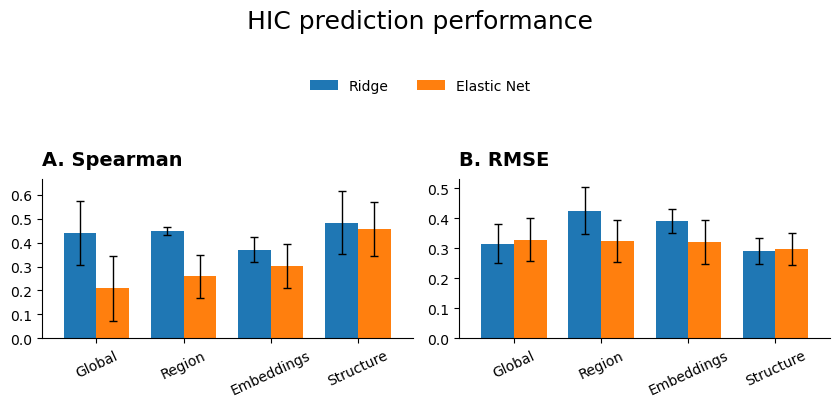

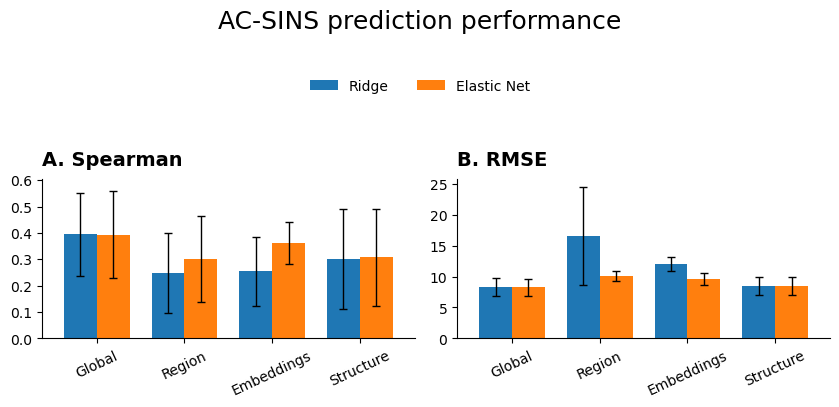

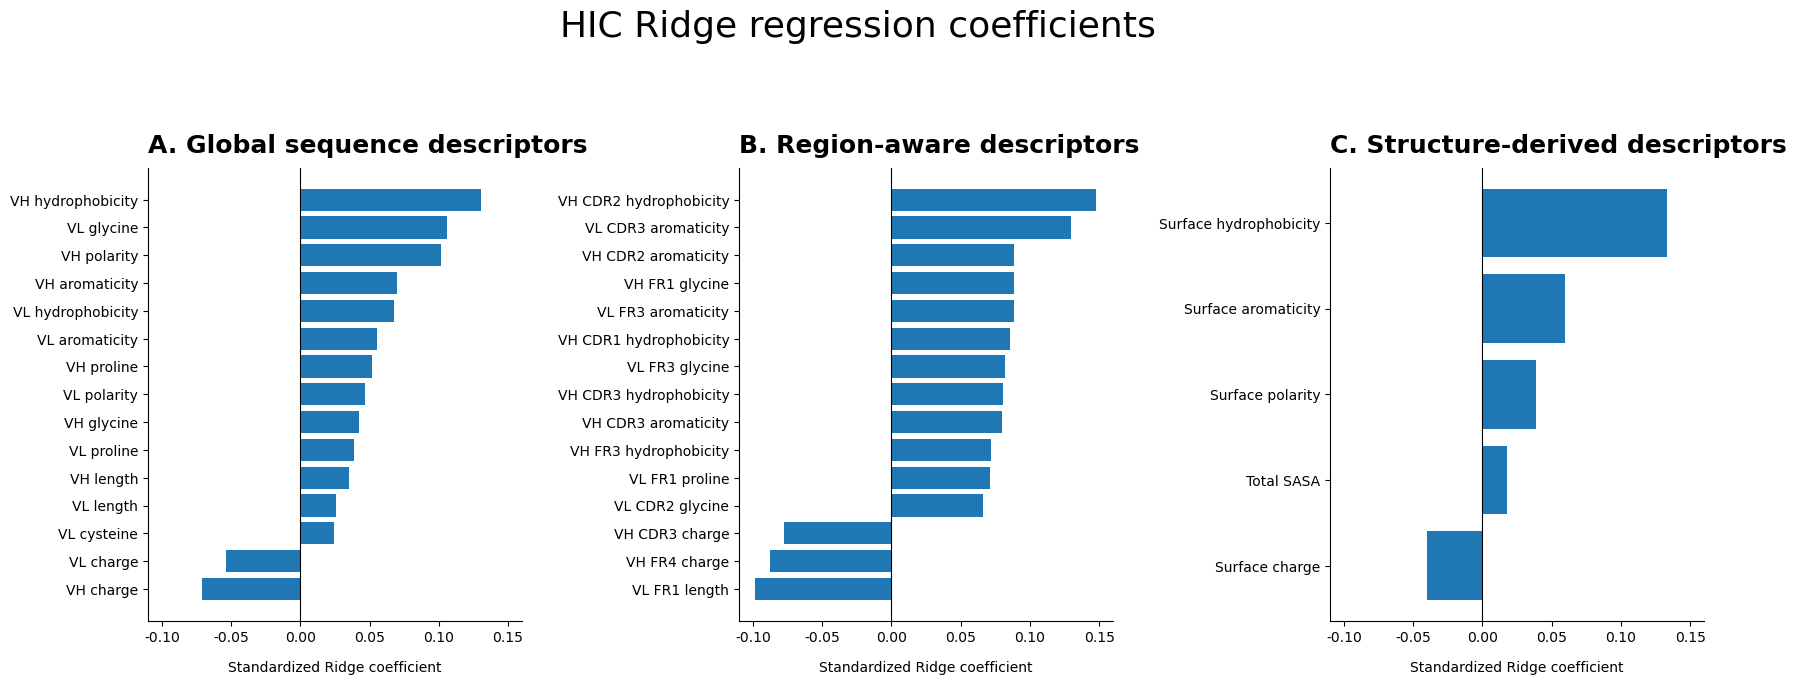

In [17]:
# =====================================
# 17. MANUSCRIPT FIGURES
# =====================================

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter


# ---------------------
# LABELS AND ORDER
# ---------------------

representation_order = [
    "Global",
    "Region",
    "Embeddings",
    "Structure"
]

model_order = [
    "Ridge",
    "ElasticNet"
]

model_labels = {
    "Ridge": "Ridge",
    "ElasticNet": "Elastic Net"
}

target_labels = {
    "HIC": "HIC",
    "AC_SINS": "AC-SINS"
}


# ---------------------
# FOLD-TO-FOLD UNCERTAINTY
# ---------------------

fold_uncertainty_df = (
    fold_results_df
    .groupby(
        [
            "Target",
            "Representation",
            "Model"
        ]
    )
    .agg(
        Spearman_mean=("Spearman", "mean"),
        Spearman_SD=("Spearman", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_SD=("RMSE", "std"),
        N_folds=("Fold", "nunique")
    )
    .reset_index()
)


# ---------------------
# VERIFY FIVE FOLDS
# ---------------------

if not (
    fold_uncertainty_df["N_folds"] == 5
).all():

    raise ValueError(
        "Fold uncertainty could not be calculated "
        "from exactly five folds for every combination."
    )


# ---------------------
# VERIFY MEANS ARE UNCHANGED
# ---------------------

mean_check = (
    results_df
    .merge(
        fold_uncertainty_df,
        on=[
            "Target",
            "Representation",
            "Model"
        ],
        how="left",
        validate="one_to_one"
    )
)

if not np.allclose(
    mean_check["Spearman"],
    mean_check["Spearman_mean"],
    rtol=0,
    atol=1e-12
):

    raise ValueError(
        "Spearman means changed when calculated "
        "from fold-level metrics."
    )

if not np.allclose(
    mean_check["RMSE"],
    mean_check["RMSE_mean"],
    rtol=0,
    atol=1e-12
):

    raise ValueError(
        "RMSE means changed when calculated "
        "from fold-level metrics."
    )


# ---------------------
# VERIFY REPRESENTATION RANKINGS
# ---------------------

for target_name in target_labels.keys():

    for model_name in model_order:

        original_subset = (
            results_df[
                (results_df["Target"] == target_name) &
                (results_df["Model"] == model_name)
            ]
            .sort_values(
                "Spearman",
                ascending=False
            )["Representation"]
            .tolist()
        )

        fold_subset = (
            fold_uncertainty_df[
                (fold_uncertainty_df["Target"] == target_name) &
                (fold_uncertainty_df["Model"] == model_name)
            ]
            .sort_values(
                "Spearman_mean",
                ascending=False
            )["Representation"]
            .tolist()
        )

        if original_subset != fold_subset:

            raise ValueError(
                f"Representation ranking changed for "
                f"{target_name}, {model_name}."
            )


# ---------------------
# SAVE UNCERTAINTY SUMMARY
# ---------------------

fold_uncertainty_df.to_csv(
    results_dir /
    "performance_fold_uncertainty.csv",
    index=False
)

print(
    "Verified: mean performance values are unchanged."
)

print(
    "Verified: representation rankings are unchanged."
)

print(
    "Saved performance_fold_uncertainty.csv"
)


# ---------------------
# PERFORMANCE FIGURE FUNCTION
# ---------------------

def plot_performance(target_name, output_name):
    """
    Plot mean fold Spearman and RMSE performance
    with ±1 SD across the five cross-validation folds.
    """

    plot_df = results_df[
        results_df["Target"] == target_name
    ].copy()

    uncertainty_df = fold_uncertainty_df[
        fold_uncertainty_df["Target"] == target_name
    ].copy()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(8.5, 3.8)
    )

    handles = None
    labels = None

    for ax, metric, panel_label in zip(
        axes,
        ["Spearman", "RMSE"],
        ["A", "B"]
    ):

        # ---------------------
        # MEAN VALUES
        # ---------------------

        metric_df = (
            plot_df
            .pivot(
                index="Representation",
                columns="Model",
                values=metric
            )
            .loc[
                representation_order,
                model_order
            ]
        )

        # ---------------------
        # FOLD-LEVEL SD
        # ---------------------

        sd_column = (
            "Spearman_SD"
            if metric == "Spearman"
            else "RMSE_SD"
        )

        sd_df = (
            uncertainty_df
            .pivot(
                index="Representation",
                columns="Model",
                values=sd_column
            )
            .loc[
                representation_order,
                model_order
            ]
        )

        # Manuscript display labels
        metric_df = metric_df.rename(
            columns=model_labels
        )

        sd_df = sd_df.rename(
            columns=model_labels
        )

        metric_df.plot(
            kind="bar",
            ax=ax,
            width=0.75,
            yerr=sd_df,
            capsize=3,
            error_kw={
                "elinewidth": 1,
                "capthick": 1
            }
        )

        if handles is None:
            handles, labels = (
                ax.get_legend_handles_labels()
            )

        ax.get_legend().remove()

        ax.set_title(
            f"{panel_label}. {metric}",
            loc="left",
            fontweight="bold",
            fontsize=14,
            pad=10
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.tick_params(
            axis="x",
            rotation=25
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # ---------------------
        # AXIS TICK GRANULARITY
        # ---------------------

        if metric == "Spearman":

            ax.yaxis.set_major_locator(
                MultipleLocator(0.1)
            )

            # Prevent SD bars from being clipped
            upper_limit = (
                metric_df.to_numpy() +
                sd_df.to_numpy()
            ).max()

            ax.set_ylim(
                0,
                max(
                    0.55,
                    upper_limit * 1.08
                )
            )

        elif (
            metric == "RMSE" and
            target_name == "HIC"
        ):

            ax.yaxis.set_major_locator(
                MultipleLocator(0.1)
            )

        elif (
            metric == "RMSE" and
            target_name == "AC_SINS"
        ):

            ax.yaxis.set_major_locator(
                MultipleLocator(5)
            )

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.91),
        ncol=2,
        frameon=False
    )

    fig.suptitle(
        (
            f"{target_labels[target_name]} "
            "prediction performance"
        ),
        fontsize=18,
        fontweight="normal",
        y=1.06
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.83]
    )

    fig.savefig(
        figures_dir / f"{output_name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        figures_dir / f"{output_name}.pdf",
        bbox_inches="tight"
    )

    plt.show()


# ---------------------
# FIGURE 3: HIC PERFORMANCE
# ---------------------

plot_performance(
    target_name="HIC",
    output_name="figure3_hic_performance"
)


# ---------------------
# FIGURE 4: AC-SINS PERFORMANCE
# ---------------------

plot_performance(
    target_name="AC_SINS",
    output_name="figure4_ac_sins_performance"
)


# ---------------------
# CLEAN FEATURE LABELS
# ---------------------

def clean_feature_label(label):
    """
    Convert code-style feature names to manuscript-style labels.
    """

    structure_labels = {
        "surface_hydrophobicity":
            "Surface hydrophobicity",

        "surface_aromaticity":
            "Surface aromaticity",

        "surface_polarity":
            "Surface polarity",

        "surface_charge":
            "Surface charge",

        "total_sasa":
            "Total SASA"
    }

    if label in structure_labels:
        return structure_labels[label]

    label = label.replace(
        "vh_",
        "VH "
    )

    label = label.replace(
        "vl_",
        "VL "
    )

    label = label.replace(
        "_",
        " "
    )

    replacements = {
        "hydrophobic": "hydrophobicity",
        "aromatic": "aromaticity",
        "polar": "polarity",
        "charge": "charge",
        "glycine": "glycine",
        "proline": "proline",
        "cysteine": "cysteine",
        "length": "length"
    }

    for old, new in replacements.items():

        label = label.replace(
            old,
            new
        )

    return label


# ---------------------
# COEFFICIENT PANEL FUNCTION
# ---------------------

def plot_coefficient_panel(
    ax,
    coefficients,
    title,
    panel_label
):
    """
    Plot one standardized Ridge coefficient panel.
    """

    coefficients = (
        coefficients.sort_values()
    )

    labels = [
        clean_feature_label(label)
        for label in coefficients.index
    ]

    ax.barh(
        labels,
        coefficients.values
    )

    ax.axvline(
        0,
        linewidth=0.8,
        color="black"
    )

    ax.set_title(
        f"{panel_label}. {title}",
        loc="left",
        fontweight="bold",
        fontsize=18,
        pad=11
    )

    ax.set_xlabel(
        "Standardized Ridge coefficient",
        labelpad=12
    )

    ax.set_ylabel("")

    # Same major tick interval across all
    # coefficient panels.
    ax.xaxis.set_major_locator(
        MultipleLocator(0.05)
    )

    # Display coefficient-axis ticks consistently
    # to two decimal places.
    ax.xaxis.set_major_formatter(
        FormatStrFormatter("%.2f")
    )

    # Same x-axis range across all three panels
    # for direct comparison of coefficient magnitude.
    ax.set_xlim(
        -0.11,
        0.16
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ---------------------
# THREE-PANEL COEFFICIENT FIGURE
# ---------------------

def plot_three_panel_coefficients(
    global_coefficients,
    region_coefficients,
    structure_coefficients,
    output_name
):
    """
    Plot Global, Region, and Structure Ridge coefficients.
    """

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17.25, 6.67)
    )

    plot_coefficient_panel(
        ax=axes[0],
        coefficients=global_coefficients,
        title="Global sequence descriptors",
        panel_label="A"
    )

    plot_coefficient_panel(
        ax=axes[1],
        coefficients=region_coefficients,
        title="Region-aware descriptors",
        panel_label="B"
    )

    plot_coefficient_panel(
        ax=axes[2],
        coefficients=structure_coefficients,
        title="Structure-derived descriptors",
        panel_label="C"
    )

    fig.suptitle(
        "HIC Ridge regression coefficients",
        fontsize=26,
        fontweight="normal",
        y=1.02
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.93],
        w_pad=2.5
    )

    fig.savefig(
        figures_dir / f"{output_name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        figures_dir / f"{output_name}.pdf",
        bbox_inches="tight"
    )

    plt.show()


# ---------------------
# FIGURE 5: HIC COEFFICIENTS
# ---------------------

plot_three_panel_coefficients(
    global_coefficients=coef_global,
    region_coefficients=coef_region,
    structure_coefficients=coef_structure,
    output_name=(
        "figure5_predictive_feature_coefficients"
    )
)

In [18]:
# =====================================
# 18. FREEZE FINAL PIPELINE ARTIFACTS
# =====================================

from pathlib import Path
import shutil
import pandas as pd


# ---------------------
# FINAL OUTPUT DIRECTORIES
# ---------------------

final_results_dir = results_dir / "final"
final_tables_dir = tables_dir / "final"
final_figures_dir = figures_dir / "final"

for path in [
    final_results_dir,
    final_tables_dir,
    final_figures_dir
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )


# ---------------------
# RESULT FILES TO FREEZE
# ---------------------

result_files = [
    "X_embeddings.csv",
    "X_structure.csv",
    "results_summary.csv",
    "fold_level_metrics.csv",
    "oof_predictions.csv",
    "mean_fold_vs_pooled_oof_metrics.csv",
    "global_coefficients.csv",
    "region_coefficients.csv",
    "structure_coefficients_optional.csv",
    "hic_ridge_fold_coefficients.csv",
    "hic_ridge_coefficient_stability.csv",
    "ac_sins_global_coefficients.csv",
    "ac_sins_region_coefficients.csv",
    "ac_sins_structure_coefficients.csv",
    "ac_sins_ridge_fold_coefficients.csv",
    "ac_sins_ridge_coefficient_stability.csv"
]


# ---------------------
# TABLE FILES TO FREEZE
# ---------------------


table_files = [
    "table1_dataset_summary.csv",
    "table1_representation_summary.csv",
    (
        "supplementary_table_S1_"
        "ridge_coefficient_stability.csv"
    ),
    (
        "supplementary_table_S1_"
        "ridge_coefficient_stability_manuscript.csv"
    )
]

# ---------------------
# FIGURE FILES TO FREEZE
# ---------------------

figure_files = [
    "figure3_hic_performance.png",
    "figure3_hic_performance.pdf",
    "figure4_ac_sins_performance.png",
    "figure4_ac_sins_performance.pdf",
    "figure5_predictive_feature_coefficients.png",
    "figure5_predictive_feature_coefficients.pdf"
]


# ---------------------
# COPY AND VALIDATE FILES
# ---------------------

def copy_final_files(
    filenames,
    source_dir,
    destination_dir
):
    """
    Copy validated pipeline outputs into a final directory.
    """

    copied_files = []

    for filename in filenames:

        source_path = source_dir / filename
        destination_path = destination_dir / filename

        if not source_path.exists():
            raise FileNotFoundError(
                f"Required file not found: {source_path}"
            )

        shutil.copy2(
            source_path,
            destination_path
        )

        copied_files.append(
            destination_path
        )

    return copied_files


final_result_files = copy_final_files(
    filenames=result_files,
    source_dir=results_dir,
    destination_dir=final_results_dir
)

final_table_files = copy_final_files(
    filenames=table_files,
    source_dir=tables_dir,
    destination_dir=final_tables_dir
)

final_figure_files = copy_final_files(
    filenames=figure_files,
    source_dir=figures_dir,
    destination_dir=final_figures_dir
)


# ---------------------
# FINAL PIPELINE SUMMARY
# ---------------------

summary_rows = [
    {
        "Representation": "Global",
        "Rows": X_global.shape[0],
        "Features": X_global.shape[1],
        "Missing_values": X_global.isna().sum().sum()
    },
    {
        "Representation": "Region",
        "Rows": X_region.shape[0],
        "Features": X_region.shape[1],
        "Missing_values": X_region.isna().sum().sum()
    },
    {
        "Representation": "Embeddings",
        "Rows": X_emb.shape[0],
        "Features": X_emb.shape[1],
        "Missing_values": X_emb.isna().sum().sum()
    },
    {
        "Representation": "Structure",
        "Rows": X_structure.shape[0],
        "Features": X_structure.shape[1],
        "Missing_values": X_structure.isna().sum().sum()
    }
]

pipeline_summary = pd.DataFrame(
    summary_rows
)

pipeline_summary.to_csv(
    final_results_dir / "pipeline_summary.csv",
    index=False
)


# ---------------------
# DISPLAY
# ---------------------

print("\n=== FINAL PIPELINE SUMMARY ===\n")
print(
    pipeline_summary.to_string(
        index=False
    )
)

print("\nTargets:")
print("HIC:", df["HIC"].notna().sum())
print("AC-SINS:", df["AC_SINS"].notna().sum())

print("\nFrozen result files:")
for path in final_result_files:
    print(path)

print("\nFrozen table files:")
for path in final_table_files:
    print(path)

print("\nFrozen figure files:")
for path in final_figure_files:
    print(path)

print(
    "\nSaved:",
    final_results_dir / "pipeline_summary.csv"
)


=== FINAL PIPELINE SUMMARY ===

Representation  Rows  Features  Missing_values
        Global   246        16               0
        Region   246       112               0
    Embeddings   246       640               0
     Structure   246         5               0

Targets:
HIC: 242
AC-SINS: 242

Frozen result files:
../results/final/X_embeddings.csv
../results/final/X_structure.csv
../results/final/results_summary.csv
../results/final/fold_level_metrics.csv
../results/final/oof_predictions.csv
../results/final/mean_fold_vs_pooled_oof_metrics.csv
../results/final/global_coefficients.csv
../results/final/region_coefficients.csv
../results/final/structure_coefficients_optional.csv
../results/final/hic_ridge_fold_coefficients.csv
../results/final/hic_ridge_coefficient_stability.csv
../results/final/ac_sins_global_coefficients.csv
../results/final/ac_sins_region_coefficients.csv
../results/final/ac_sins_structure_coefficients.csv
../results/final/ac_sins_ridge_fold_coefficients.csv
../r